In [1]:

from lightgbm import LGBMClassifier

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    RocCurveDisplay
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
pd.set_option("display.max_columns", None)

In [2]:
application = pd.read_csv(
    "../data/raw/application_train.csv"
)

bureau = pd.read_csv(
    "../data/raw/application_train.csv"
)

previous = pd.read_csv(
    "../data/raw/previous_application.csv"
)

installments = pd.read_csv(
    "../data/raw/installments_payments.csv"
)

credit_card = pd.read_csv(
    "../data/raw/credit_card_balance.csv"
)

pos_cash = pd.read_csv(
    "../data/raw/POS_CASH_balance.csv"
)

In [3]:
for name, df in {
    "application": application,
    "bureau": bureau,
    "previous": previous,
    "installments": installments,
    "credit_card": credit_card,
    "pos_cash": pos_cash
}.items():

    print(name, df.shape)

application (307511, 122)
bureau (1716428, 17)
previous (1670214, 37)
installments (13605401, 8)
credit_card (3840312, 23)
pos_cash (10001358, 8)


In [4]:
bureau_count = (
    bureau.groupby("SK_ID_CURR")
    .size()
    .reset_index(name="bureau_count")
)

In [5]:
bureau_credit_mean = (
    bureau.groupby("SK_ID_CURR")
    ["AMT_CREDIT_SUM"]
    .mean()
    .reset_index(name="bureau_credit_mean")
)
avg_overdue = (
    bureau.groupby("SK_ID_CURR")
    ["AMT_CREDIT_SUM_OVERDUE"]
    .mean()
    .reset_index(name="avg_overdue")
)

In [6]:
bureau_overdue_max = (
    bureau.groupby("SK_ID_CURR")
    ["AMT_CREDIT_SUM_OVERDUE"]
    .max()
    .reset_index(name="bureau_overdue_max")
)
avg_debt = (
    bureau.groupby("SK_ID_CURR")
    ["AMT_CREDIT_SUM_DEBT"]
    .mean()
    .reset_index(name="avg_debt")
)
max_debt = (
    bureau.groupby("SK_ID_CURR")
    ["AMT_CREDIT_SUM_DEBT"]
    .max()
    .reset_index(name="max_debt")
)

In [7]:
active_loans = (
    bureau[bureau["CREDIT_ACTIVE"] == "Active"]
    .groupby("SK_ID_CURR")
    .size()
    .reset_index(name="active_loans")
)
closed_loans = (
    bureau[bureau["CREDIT_ACTIVE"] == "Closed"]
    .groupby("SK_ID_CURR")
    .size()
    .reset_index(name="closed_loans")
)

In [8]:
bureau_features = bureau_count
for df in [
    bureau_credit_mean,
    bureau_overdue_max,
    active_loans,
    closed_loans,
    avg_debt,
    max_debt,
    avg_overdue
]:
   bureau_features = bureau_features.merge(
    df,
    on="SK_ID_CURR",
    how="left")

In [9]:
bureau_features.head()

,SK_ID_CURR,bureau_count,bureau_credit_mean,bureau_overdue_max,active_loans,closed_loans,avg_debt,max_debt,avg_overdue
0,100001,7,207623.571429,0.0,3.0,4.0,85240.928571,373239.0,0.0
1,100002,8,108131.945625,0.0,2.0,6.0,49156.200000,245781.0,0.0
2,100003,4,254350.125000,0.0,1.0,3.0,0.000000,0.0,0.0
3,100004,2,94518.900000,0.0,NaN,2.0,0.000000,0.0,0.0
4,100005,3,219042.000000,0.0,2.0,1.0,189469.500000,543087.0,0.0


In [10]:
application_with_bureau = application.merge(
    bureau_features,
    on="SK_ID_CURR",
    how="left"
)

In [11]:
print(application.shape)
print(application_with_bureau.shape)

(307511, 122)
(307511, 130)


In [12]:
application_with_bureau[
    [
        "bureau_count",
        "bureau_credit_mean",
        "bureau_overdue_max",
        "active_loans"
    ]
].isnull().mean() * 100

bureau_count          14.314935
bureau_credit_mean    14.315260
bureau_overdue_max    14.314935
active_loans          29.384640
dtype: float64

In [13]:
total_credit = (
    bureau.groupby("SK_ID_CURR")
    ["AMT_CREDIT_SUM"]
    .sum()
    .reset_index(name="total_credit")
)

In [14]:
application_with_bureau = application_with_bureau.merge(
    total_credit,
    on="SK_ID_CURR",
    how="left"
)
application_with_bureau["debt_credit_ratio"] = (
    application_with_bureau["avg_debt"] /
    application_with_bureau["total_credit"]
)
application_with_bureau["debt_credit_ratio"] = (
    application_with_bureau["debt_credit_ratio"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)
application_with_bureau["active_loan_ratio"] = (
    application_with_bureau["active_loans"] /
    application_with_bureau["bureau_count"]
)
application_with_bureau["closed_loan_ratio"] = (
    application_with_bureau["closed_loans"] /
    application_with_bureau["bureau_count"]
)

In [15]:
ratio_cols = [
    "debt_credit_ratio",
    "active_loan_ratio",
    "closed_loan_ratio"
]

application_with_bureau[ratio_cols] = (
    application_with_bureau[ratio_cols]
    .fillna(0)
)

In [16]:
application_with_bureau[
    ratio_cols
].describe()

,debt_credit_ratio,active_loan_ratio,closed_loan_ratio
count,307511.000000,307511.000000,307511.000000
mean,0.087745,0.353855,0.499640
std,0.189296,0.320026,0.351212
min,-35.057846,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.018832,0.333333,0.521739
75%,0.089703,0.500000,0.750000
max,7.789100,1.000000,1.000000


In [17]:
X = application_with_bureau.drop(
    columns=["TARGET", "SK_ID_CURR"]
)
y = application_with_bureau["TARGET"]

print(X.shape)
print(y.shape)

(307511, 132)
(307511,)


In [18]:
X["DAYS_EMPLOYED"] = (
    X["DAYS_EMPLOYED"]
    .replace(365243, np.nan)        
)
#because contains unexpected days which is impossible like 365243 we will convert it to missing

In [19]:
num_cols = X.select_dtypes(
    include=np.number
).columns.tolist()

cat_cols = X.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numerical:", len(num_cols))
print("Categorical:", len(cat_cols))

Numerical: 116
Categorical: 16


In [20]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.1765,  # gives ~15% validation overall
    random_state=42,
    stratify=y_train_val
)

In [21]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])
categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

In [22]:
preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        num_cols
    ),
    (
        "categorical",
        categorical_pipeline,
        cat_cols
    )
])

In [23]:
lgbm_model = Pipeline([
    ("preprocessor", preprocessor),

    (
        "classifier",
        LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            num_leaves=31,
            class_weight="balanced",
            random_state=42
        )
    )
])

In [24]:
lgbm_model.fit(
    X_train,
    y_train
)
y_pred = lgbm_model.predict(X_test)

y_prob = lgbm_model.predict_proba(
    X_test
)[:,1]
print(
    classification_report(
        y_test,
        y_pred
    )
)

C:\Users\vrund\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\vrund\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\vrund\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\vrund\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

[LightGBM] [Info] Number of positive: 17377, number of negative: 197872
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.104333 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13488
[LightGBM] [Info] Number of data points in the train set: 215249, number of used features: 245
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

C:\Users\vrund\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\vrund\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       0.96      0.72      0.82     42403
           1       0.17      0.67      0.28      3724

    accuracy                           0.72     46127
   macro avg       0.57      0.70      0.55     46127
weighted avg       0.90      0.72      0.78     46127



[[30619 11784]
 [ 1228  2496]]


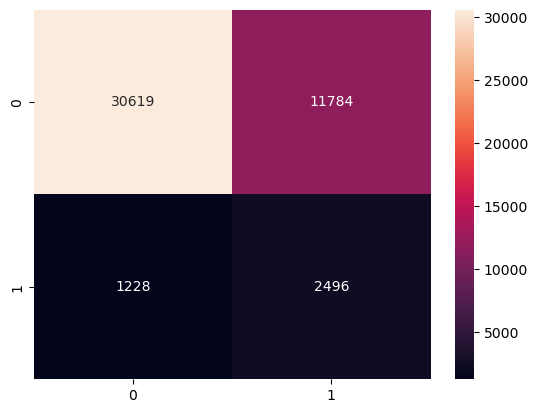

In [25]:
cm = confusion_matrix(
    y_test,
    y_pred
)
print(cm)
sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.show()

In [26]:
auc = roc_auc_score(
    y_test,
    y_prob
)

print(
    f"ROC-AUC: {auc:.4f}"
)

ROC-AUC: 0.7635


In [27]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    lgbm_model,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

print(cv_scores)
print(cv_scores.mean())


[0.7535981  0.75582255 0.76430867 0.75617492 0.75767852]
0.7575165514831634


In [28]:
inst = installments.copy()

# Delay features
inst["PAYMENT_DELAY"] = (
    inst["DAYS_ENTRY_PAYMENT"]
    - inst["DAYS_INSTALMENT"]
)

inst["DAYS_LATE"] = inst["PAYMENT_DELAY"].clip(lower=0)

# Late payment flags
inst["LATE_PAYMENT"] = (inst["DAYS_LATE"] > 0).astype(int)
inst["LATE_30"] = (inst["DAYS_LATE"] > 30).astype(int)
inst["LATE_60"] = (inst["DAYS_LATE"] > 60).astype(int)
inst["LATE_90"] = (inst["DAYS_LATE"] > 90).astype(int)

# Payment behavior
inst["PAYMENT_RATIO"] = (
    inst["AMT_PAYMENT"] / inst["AMT_INSTALMENT"]
)

inst["PAYMENT_RATIO"] = (
    inst["PAYMENT_RATIO"]
    .replace([np.inf, -np.inf], np.nan)
)

inst["PAYMENT_DIFF"] = (
    inst["AMT_PAYMENT"]
    - inst["AMT_INSTALMENT"]
)

# Aggregate
installment_features = (
    inst.groupby("SK_ID_CURR")
    .agg({
        "SK_ID_PREV": "nunique",

        "DAYS_LATE": ["mean", "max", "std"],

        "PAYMENT_DELAY": ["mean", "min"],

        "LATE_PAYMENT": ["mean", "sum"],
        "LATE_30": "mean",
        "LATE_60": "mean",
        "LATE_90": "mean",

        "PAYMENT_RATIO": ["mean", "min", "max"],

        "PAYMENT_DIFF": ["mean", "min", "max"],

        "AMT_PAYMENT": ["mean", "sum"],
        "AMT_INSTALMENT": ["mean", "sum"]
    })
    .reset_index()
)

In [29]:
installment_features.columns = [
    "SK_ID_CURR",

    "inst_num_prev_loans",

    "inst_avg_days_late",
    "inst_max_days_late",
    "inst_std_days_late",

    "inst_avg_payment_delay",
    "inst_min_payment_delay",

    "inst_late_payment_ratio",
    "inst_num_late_payments",

    "inst_late30_ratio",
    "inst_late60_ratio",
    "inst_late90_ratio",

    "inst_avg_payment_ratio",
    "inst_min_payment_ratio",
    "inst_max_payment_ratio",

    "inst_avg_payment_diff",
    "inst_min_payment_diff",
    "inst_max_payment_diff",

    "inst_avg_payment",
    "inst_total_payment",

    "inst_avg_installment",
    "inst_total_installment"
]

In [30]:
application_full = application_with_bureau.merge(installment_features,on="SK_ID_CURR",how="left")
print(application_with_bureau.shape)

print(application_full.shape)

application_full[
    [
        "inst_avg_days_late",
        "inst_max_days_late",
        "inst_late_payment_ratio"
    ]
].isnull().mean() * 100


(307511, 134)
(307511, 155)


inst_avg_days_late         5.162742
inst_max_days_late         5.162742
inst_late_payment_ratio    5.160141
dtype: float64

In [31]:
X = application_full.drop(
    columns=["TARGET", "SK_ID_CURR"]
)
y = application_full["TARGET"]

print(X.shape)
print(y.shape)

(307511, 153)
(307511,)


In [32]:
X["DAYS_EMPLOYED"] = (
    X["DAYS_EMPLOYED"]
    .replace(365243, np.nan)        
)
#because contains unexpected days which is impossible like 365243 we will convert it to missing

In [33]:
num_cols = X.select_dtypes(
    include=np.number
).columns.tolist()

cat_cols = X.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numerical:", len(num_cols))
print("Categorical:", len(cat_cols))

Numerical: 137
Categorical: 16


In [34]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.1765,  # gives ~15% validation overall
    random_state=42,
    stratify=y_train_val
)
X_train.head()

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,bureau_count,bureau_credit_mean,bureau_overdue_max,active_loans,closed_loans,avg_debt,max_debt,avg_overdue,total_credit,debt_credit_ratio,active_loan_ratio,closed_loan_ratio,inst_num_prev_loans,inst_avg_days_late,inst_max_days_late,inst_std_days_late,inst_avg_payment_delay,inst_min_payment_delay,inst_late_payment_ratio,inst_num_late_payments,inst_late30_ratio,inst_late60_ratio,inst_late90_ratio,inst_avg_payment_ratio,inst_min_payment_ratio,inst_max_payment_ratio,inst_avg_payment_diff,inst_min_payment_diff,inst_max_payment_diff,inst_avg_payment,inst_total_payment,inst_avg_installment,inst_total_installment
69040,Cash loans,F,N,N,0,90000.0,225000.0,12006.0,225000.0,Other_B,Working,Secondary / secondary special,Single / not married,House / apartment,0.026392,-19386,-3063.0,-1372.0,-2933,NaN,1,1,1,1,1,0,Private service staff,1.0,2,2,THURSDAY,18,0,0,0,0,0,0,Self-employed,NaN,0.456546,NaN,0.1804,0.1749,0.9801,NaN,NaN,0.0,0.4138,0.1667,NaN,0.2317,NaN,0.1038,NaN,0.274,0.1838,0.1815,0.9801,NaN,NaN,0.0,0.4138,0.1667,NaN,0.237,NaN,0.1082,NaN,0.2901,0.1822,0.1749,0.9801,NaN,NaN,0.0,0.4138,0.1667,NaN,0.2358,NaN,0.1057,NaN,0.2798,NaN,block of flats,0.1352,Panel,No,0.0,0.0,0.0,0.0,-2160.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000,0.000,3.0,0.006061,1.0,0.077850,-5.430303,-30.0,0.006061,1.0,0.0,0.0,0.0,1.117880,1.000000,10.92854,1295.454545,0.0,75829.815,10505.887091,1733471.370,9210.432545,1519721.370
250273,Cash loans,F,Y,Y,0,112500.0,810000.0,34447.5,810000.0,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.019101,-18042,-4190.0,-8741.0,-1562,14.0,1,1,0,1,0,0,Core staff,2.0,2,2,SATURDAY,12,0,0,0,0,1,1,Postal,0.471610,0.356790,0.470456,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

In [35]:
lgbm = Pipeline([
    ("preprocessor", preprocessor),

    (
        "classifier",
        LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            num_leaves=31,
            class_weight="balanced",
            random_state=42
        )
    )
])

In [36]:

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    lgbm,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

print(cv_scores)
print(cv_scores.mean())

[0.7535981  0.75582255 0.76430867 0.75617492 0.75767852]
0.7575165514831634


In [37]:
lgbm.fit(
    X_train,
    y_train
)
y_pred = lgbm.predict(X_test)

y_prob = lgbm.predict_proba(
    X_test
)[:,1]
print(
    classification_report(
        y_test,
        y_pred
    )
)

[LightGBM] [Info] Number of positive: 17377, number of negative: 197872
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.071417 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13488
[LightGBM] [Info] Number of data points in the train set: 215249, number of used features: 245
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

C:\Users\vrund\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       0.96      0.72      0.82     42403
           1       0.17      0.67      0.28      3724

    accuracy                           0.72     46127
   macro avg       0.57      0.70      0.55     46127
weighted avg       0.90      0.72      0.78     46127



C:\Users\vrund\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [38]:

auc = roc_auc_score(
    y_test,
    y_prob
)

print(
    f"ROC-AUC: {auc:.4f}"
)

ROC-AUC: 0.7635


In [39]:
classifier = lgbm.named_steps["classifier"]

importance_df = pd.DataFrame({
    "feature": preprocessor.get_feature_names_out(),
    "importance": classifier.feature_importances_
})

importance_df.sort_values(
    "importance",
    ascending=False
).head(50)

,feature,importance
29,numeric__EXT_SOURCE_3,559
27,numeric__EXT_SOURCE_1,507
28,numeric__EXT_SOURCE_2,486
6,numeric__DAYS_BIRTH,415
2,numeric__AMT_CREDIT,385
7,numeric__DAYS_EMPLOYED,356
3,numeric__AMT_ANNUITY,350
4,numeric__AMT_GOODS_PRICE,270
105,numeric__bureau_credit_mean,260
8,numeric__DAYS_REGISTRATION,250


In [40]:
prev_num_applications = (previous.groupby("SK_ID_CURR").size().reset_index(name="prev_num_applications"))
prev_approved = (
    previous[
        previous["NAME_CONTRACT_STATUS"] == "Approved"
    ]
    .groupby("SK_ID_CURR")
    .size()
    .reset_index(name="prev_approved_count")
)
prev_refused = (
    previous[
        previous["NAME_CONTRACT_STATUS"] == "Refused"
    ]
    .groupby("SK_ID_CURR")
    .size()
    .reset_index(name="prev_refused_count")
)
prev_features = prev_num_applications.copy()

for df in [prev_approved, prev_refused]:
    prev_features = prev_features.merge(
        df,
        on="SK_ID_CURR",
        how="left"
    )

prev_features.fillna(0, inplace=True)
prev_features["prev_approval_rate"] = (
    prev_features["prev_approved_count"]
    / prev_features["prev_num_applications"]
)
prev_features["prev_refusal_rate"] = (
    prev_features["prev_refused_count"]
    / prev_features["prev_num_applications"]
)
avg_credit = (
    previous
    .groupby("SK_ID_CURR")
    ["AMT_CREDIT"]
    .mean()
    .reset_index(name="prev_avg_credit")
)
avg_annuity = (
    previous
    .groupby("SK_ID_CURR")
    ["AMT_ANNUITY"]
    .mean()
    .reset_index(name="prev_avg_annuity"))
avg_goods = (
    previous
    .groupby("SK_ID_CURR")
    ["AMT_GOODS_PRICE"]
    .mean()
    .reset_index(name="prev_avg_goods_price")
)
previous["credit_approval_ratio"] = (
    previous["AMT_CREDIT"]
    / previous["AMT_APPLICATION"]
)

previous["credit_approval_ratio"] = (
    previous["credit_approval_ratio"]
    .replace([np.inf, -np.inf], np.nan)
)
approval_ratio = (
    previous
    .groupby("SK_ID_CURR")
    ["credit_approval_ratio"]
    .mean()
    .reset_index(name="prev_credit_approval_ratio")
)
for df in [
    avg_credit,
    avg_annuity,
    avg_goods,
    approval_ratio
]:
    prev_features = prev_features.merge(
        df,
        on="SK_ID_CURR",
        how="left"
    )

In [41]:
application_final = application_with_bureau.merge(
    prev_features,
    on="SK_ID_CURR",
    how="left"
)

In [42]:
X = application_final.drop(
    columns=["TARGET", "SK_ID_CURR"]
)
y = application_final["TARGET"]

print(X.shape)
print(y.shape)
X["DAYS_EMPLOYED"] = (
    X["DAYS_EMPLOYED"]
    .replace(365243, np.nan)        
)
num_cols = X.select_dtypes(
    include=np.number
).columns.tolist()

cat_cols = X.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numerical:", len(num_cols))
print("Categorical:", len(cat_cols))
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.1765,  # gives ~15% validation overall
    random_state=42,
    stratify=y_train_val
)
X_train.head()

(307511, 141)
(307511,)
Numerical: 125
Categorical: 16


,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,bureau_count,bureau_credit_mean,bureau_overdue_max,active_loans,closed_loans,avg_debt,max_debt,avg_overdue,total_credit,debt_credit_ratio,active_loan_ratio,closed_loan_ratio,prev_num_applications,prev_approved_count,prev_refused_count,prev_approval_rate,prev_refusal_rate,prev_avg_credit,prev_avg_annuity,prev_avg_goods_price,prev_credit_approval_ratio
69040,Cash loans,F,N,N,0,90000.0,225000.0,12006.0,225000.0,Other_B,Working,Secondary / secondary special,Single / not married,House / apartment,0.026392,-19386,-3063.0,-1372.0,-2933,NaN,1,1,1,1,1,0,Private service staff,1.0,2,2,THURSDAY,18,0,0,0,0,0,0,Self-employed,NaN,0.456546,NaN,0.1804,0.1749,0.9801,NaN,NaN,0.0,0.4138,0.1667,NaN,0.2317,NaN,0.1038,NaN,0.274,0.1838,0.1815,0.9801,NaN,NaN,0.0,0.4138,0.1667,NaN,0.237,NaN,0.1082,NaN,0.2901,0.1822,0.1749,0.9801,NaN,NaN,0.0,0.4138,0.1667,NaN,0.2358,NaN,0.1057,NaN,0.2798,NaN,block of flats,0.1352,Panel,No,0.0,0.0,0.0,0.0,-2160.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000,0.000,3.0,2.0,0.0,0.666667,0.000000,158125.500000,12376.080000,218925.000,1.085803
250273,Cash loans,F,Y,Y,0,112500.0,810000.0,34447.5,810000.0,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.019101,-18042,-4190.0,-8741.0,-1562,14.0,1,1,0,1,0,0,Core staff,2.0,2,2,SATURDAY,12,0,0,0,0,1,1,Postal,0.471610,0.356790,0.470456,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,0.0,7.0,0.0,-2315.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,1.0,5.0,8.0,120192.1875,0.0,5.0,3.0,142479.000000,252171.0,0.0,961537.500,0.148178,0.625,0.375,4.0,3.0,0.0,0.750000,0.000000,150963.750000,7464.57

In [43]:
lgbm = Pipeline([
    ("preprocessor", preprocessor),

    (
        "classifier",
        LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            num_leaves=31,
            class_weight="balanced",
            random_state=42
        )
    )
])
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    lgbm,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

print(cv_scores)
print(cv_scores.mean())

[0.7535981  0.75582255 0.76430867 0.75617492 0.75767852]
0.7575165514831634


In [44]:
lgbm.fit(
    X_train,
    y_train
)
y_pred = lgbm.predict(X_test)

y_prob = lgbm.predict_proba(
    X_test
)[:,1]
print(
    classification_report(
        y_test,
        y_pred
    )
)
auc = roc_auc_score(
    y_test,
    y_prob
)

print(
    f"ROC-AUC: {auc:.4f}"
)

[LightGBM] [Info] Number of positive: 17377, number of negative: 197872
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.048705 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13488
[LightGBM] [Info] Number of data points in the train set: 215249, number of used features: 245
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

C:\Users\vrund\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       0.96      0.72      0.82     42403
           1       0.17      0.67      0.28      3724

    accuracy                           0.72     46127
   macro avg       0.57      0.70      0.55     46127
weighted avg       0.90      0.72      0.78     46127

ROC-AUC: 0.7635


C:\Users\vrund\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [45]:
classifier = lgbm.named_steps["classifier"]

importance_df = pd.DataFrame({
    "feature": preprocessor.get_feature_names_out(),
    "importance": classifier.feature_importances_
})

importance_df.sort_values(
    "importance",
    ascending=False
).head(50)

,feature,importance
29,numeric__EXT_SOURCE_3,559
27,numeric__EXT_SOURCE_1,507
28,numeric__EXT_SOURCE_2,486
6,numeric__DAYS_BIRTH,415
2,numeric__AMT_CREDIT,385
7,numeric__DAYS_EMPLOYED,356
3,numeric__AMT_ANNUITY,350
4,numeric__AMT_GOODS_PRICE,270
105,numeric__bureau_credit_mean,260
8,numeric__DAYS_REGISTRATION,250


In [46]:
from catboost import CatBoostClassifier
cat_model= Pipeline([
    ("preprocessor", preprocessor),

    (
        "classifier",
        CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    eval_metric="AUC",
    verbose=100,
    random_seed=42
)
    )
])
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(
   cat_model,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

print(cv_scores)

[0.75722484 0.76062802 0.76768283 0.76146269 0.76172338]


In [47]:
from xgboost import XGBClassifier
xgb = Pipeline([
    ("preprocessor", preprocessor),

    (
        "classifier",
   XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="auc",
    random_state=42
)
    )
])
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
   xgb ,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

print(cv_scores)
print(cv_scores.mean())

[0.7555154  0.75972312 0.76537167 0.7590702  0.76034678]
0.7600054323637129


In [48]:
classifier = cat_model.named_steps["classifier"]

importance_df = pd.DataFrame({
    "feature": preprocessor.get_feature_names_out(),
    "importance": classifier.feature_importances_
})

importance_df.sort_values(
    "importance",
    ascending=False
).head(50)

,feature,importance
0,numeric__CNT_CHILDREN,None
1,numeric__AMT_INCOME_TOTAL,None
2,numeric__AMT_CREDIT,None
3,numeric__AMT_ANNUITY,None
4,numeric__AMT_GOODS_PRICE,None
5,numeric__REGION_POPULATION_RELATIVE,None
6,numeric__DAYS_BIRTH,None
7,numeric__DAYS_EMPLOYED,None
8,numeric__DAYS_REGISTRATION,None
9,numeric__DAYS_ID_PUBLISH,None


In [49]:
cat_model.fit(
    X_train,
    y_train
)
y_pred = cat_model.predict(X_test)

y_prob = cat_model.predict_proba(
    X_test
)[:,1]
print(
    classification_report(
        y_test,
        y_pred
    )
)
auc = roc_auc_score(
    y_test,
    y_prob
)

print(
    f"ROC-AUC: {auc:.4f}"
)

0:	total: 170ms	remaining: 2m 49s
100:	total: 2.53s	remaining: 22.5s
200:	total: 4.77s	remaining: 19s
300:	total: 6.99s	remaining: 16.2s
400:	total: 9.16s	remaining: 13.7s
500:	total: 11.3s	remaining: 11.3s
600:	total: 13.5s	remaining: 8.97s
700:	total: 15.7s	remaining: 6.69s
800:	total: 17.9s	remaining: 4.45s
900:	total: 20.1s	remaining: 2.21s
999:	total: 22.3s	remaining: 0us
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     42403
           1       0.57      0.03      0.05      3724

    accuracy                           0.92     46127
   macro avg       0.75      0.51      0.50     46127
weighted avg       0.89      0.92      0.88     46127

ROC-AUC: 0.7672


In [50]:
importance_df.sort_values(
    "importance",
    ascending=True
).head(50)

,feature,importance
0,numeric__CNT_CHILDREN,None
1,numeric__AMT_INCOME_TOTAL,None
2,numeric__AMT_CREDIT,None
3,numeric__AMT_ANNUITY,None
4,numeric__AMT_GOODS_PRICE,None
5,numeric__REGION_POPULATION_RELATIVE,None
6,numeric__DAYS_BIRTH,None
7,numeric__DAYS_EMPLOYED,None
8,numeric__DAYS_REGISTRATION,None
9,numeric__DAYS_ID_PUBLISH,None


In [51]:
xgb.fit(
    X_train,
    y_train
)
y_pred = xgb.predict(X_test)

y_prob = xgb.predict_proba(
    X_test
)[:,1]
print(
    classification_report(
        y_test,
        y_pred
    )
)
auc = roc_auc_score(
    y_test,
    y_prob
)

print(
    f"ROC-AUC: {auc:.4f}"
)

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     42403
           1       0.60      0.03      0.06      3724

    accuracy                           0.92     46127
   macro avg       0.76      0.51      0.51     46127
weighted avg       0.90      0.92      0.89     46127

ROC-AUC: 0.7655


In [52]:
cat_pred = cat_model.predict_proba(X_test)[:,1]
xgb_pred = xgb.predict_proba(X_test)[:,1]
lgb_pred = lgbm.predict_proba(X_test)[:,1]
ensemble_pred = (
    cat_pred +
    xgb_pred +
    lgb_pred
) / 3

C:\Users\vrund\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [53]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, ensemble_pred)

np.float64(0.7665165428555166)

In [54]:
cat= cat_model.named_steps["classifier"]

In [56]:
X_train_transformed = (
    cat_model.named_steps["preprocessor"]
    .transform(X_train)
)

X_test_transformed = (
    cat_model.named_steps["preprocessor"]
    .transform(X_test)
)
feature_names = (
    cat_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

In [62]:
import shap

explainer = shap.TreeExplainer(cat)

In [68]:
X_sample = X_test_transformed[:1000]

shap_values = explainer.shap_values(X_sample)

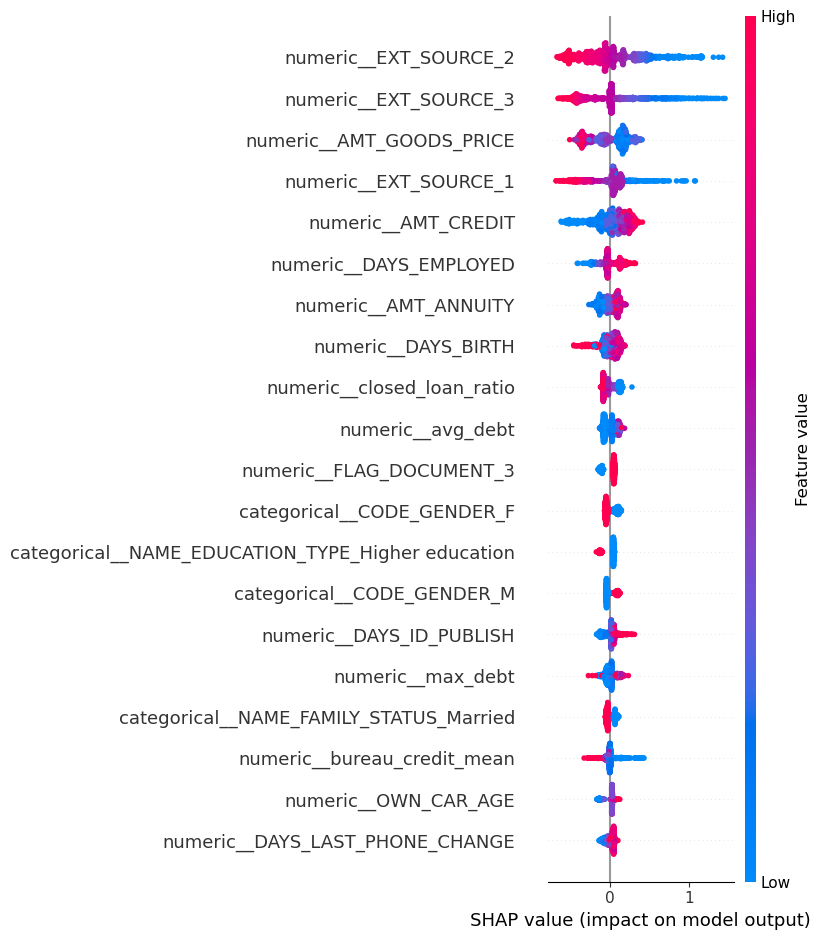

In [69]:
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names
)

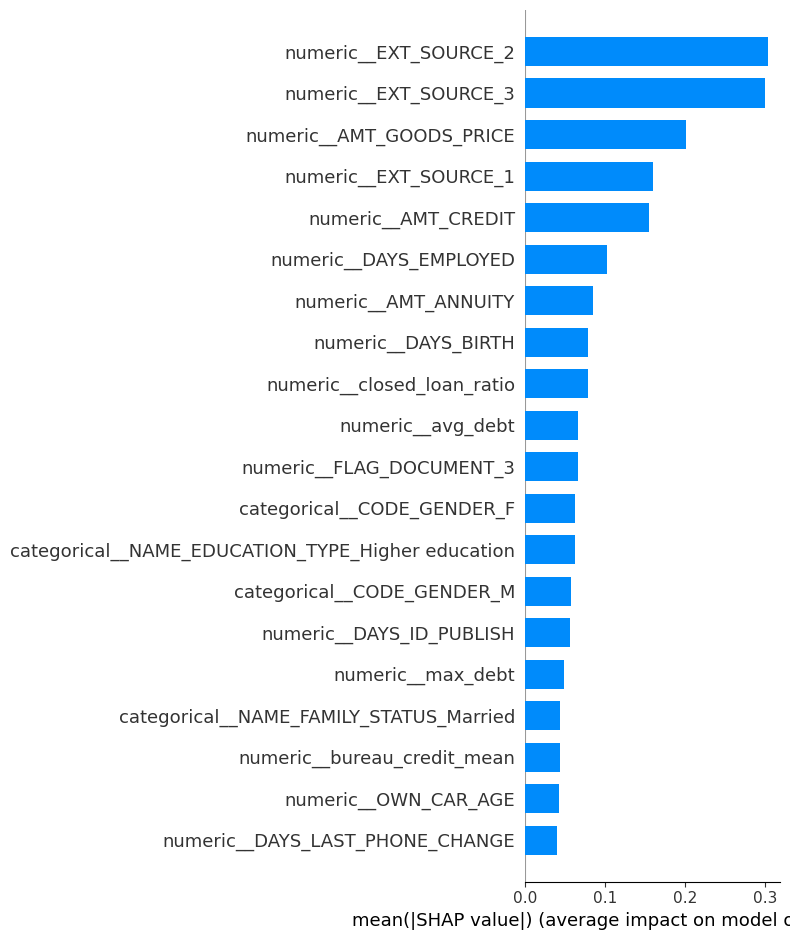

In [70]:
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names,
    plot_type="bar"
)

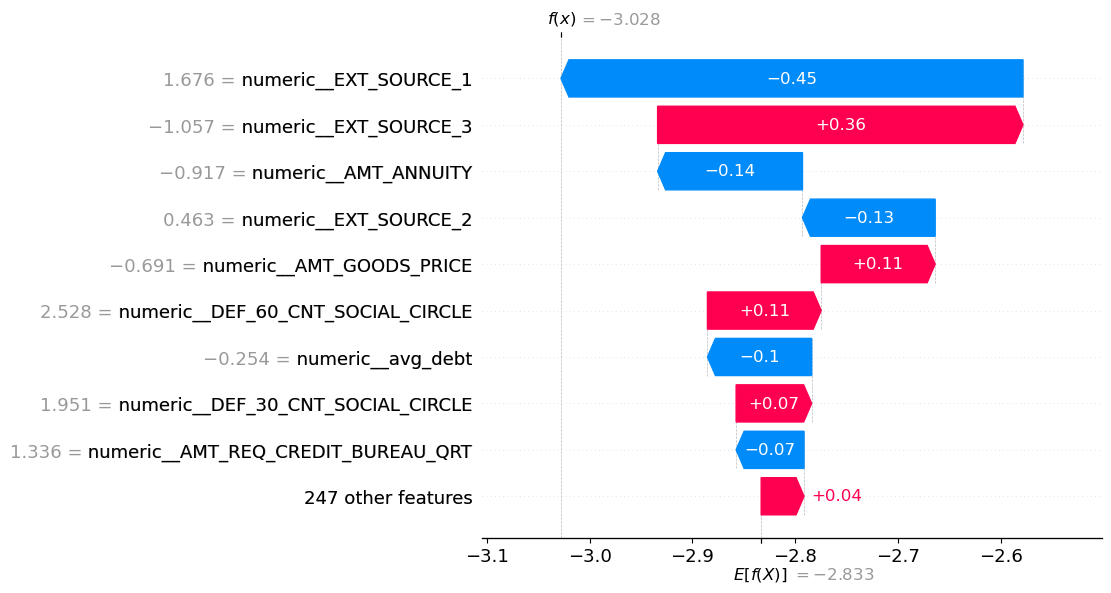

In [71]:
customer_id = 10

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[customer_id],
        base_values=explainer.expected_value,
        data=X_sample[customer_id],
        feature_names=feature_names
    )
)

In [72]:
import pandas as pd
import numpy as np

shap_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "mean_abs_shap",
    ascending=False
)

shap_importance.head(20)

,feature,mean_abs_shap
28,numeric__EXT_SOURCE_2,0.303654
29,numeric__EXT_SOURCE_3,0.300231
4,numeric__AMT_GOODS_PRICE,0.200869
27,numeric__EXT_SOURCE_1,0.159858
2,numeric__AMT_CREDIT,0.155315
7,numeric__DAYS_EMPLOYED,0.102898
3,numeric__AMT_ANNUITY,0.085351
6,numeric__DAYS_BIRTH,0.079172
115,numeric__closed_loan_ratio,0.078931
109,numeric__avg_debt,0.067098


In [73]:
fp = X_test[(y_test == 0) & (y_pred == 1)]
fn = X_test[(y_test == 1) & (y_pred == 0)]

print("False Positives:", len(fp))
print("False Negatives:", len(fn))

False Positives: 78
False Negatives: 3608


In [74]:
fp.describe()
fn.describe()

,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,bureau_count,bureau_credit_mean,bureau_overdue_max,active_loans,closed_loans,avg_debt,max_debt,avg_overdue,total_credit,debt_credit_ratio,active_loan_ratio,closed_loan_ratio,prev_num_applications,prev_approved_count,prev_refused_count,prev_approval_rate,prev_refusal_rate,prev_avg_credit,prev_avg_annuity,prev_avg_goods_price,prev_credit_approval_ratio
count,3608.000000,3.608000e+03,3.608000e+03,3608.000000,3.607000e+03,3608.000000,3608.000000,3142.000000,3608.000000,3608.000000,1126.000000,3608.0,3608.000000,3608.000000,3608.000000,3608.000000,3608.000000,3608.000000,3608.00000,3608.000000,3608.000000,3608.000000,3608.000000,3608.000000,3608.000000,3608.000000,3608.000000,1457.000000,3600.000000,2774.000000,1521.000000,1246.000000,1600.000000,1008.000000,905.000000,1404.000000,1537.000000,1557.000000,969.000000,1233.000000,948.000000,1554.000000,923.000000,1360.000000,1521.000000,1246.000000,1600.000000,1008.000000,905.000000,1404.000000,1537.000000,1557.000000,969.000000,1233.000000,948.000000,1554.000000,923.000000,1360.000000,1521.000000,1246.000000,1600.000000,1008.000000,905.000000,1404.000000,1537.000000,1557.000000,969.000000,1233.000000,948.000000,1554.000000,923.000000,1360.000000,1616.000000,3606.000000,3606.000000,3606.000000,3606.000000,3608.000000,3608.0,3608.000000,3608.0,3608.000000,3608.000000,3608.0,3608.000000,3608.000000,3608.0,3608.000000,3608.0,3608.000000,3608.000000,3608.000000,3608.000000,3608.000000,3608.000000,3608.000000,3608.000000,3608.000000,2990.000000,2990.000000,2990.000000,2990.000000,2990.000000,2990.000000,2964.000000,2.964000e+03,2964.000000,2556.000000,2426.000000,2.886000e+03,2.886000e+03,2964.000000,2.964000e+03,3608.000000,3608.000000,3608.000000,3460.000000,3460.000000,3460.000000,3460.000000,3460.000000,3.460000e+03,3458.000000,3.452000e+03,3452.000000
mean,0.454545,1.606691e+05,5.588705e+05,26383.876663,4.900443e+05,0.019218,-15041.120288,-1851.191598,-4501.614191,-2700.129712,13.671403,1.0,0.870843,0.233647,0.999446,0.246120,0.049335,2.175166,2.15133,2.128049,11.855322,0.020787,0.058204,0.042683,0.113359,0.295177,0.21313

In [77]:
pos_features = pos_cash.groupby("SK_ID_CURR").agg({
    "SK_ID_PREV": "nunique",
    "MONTHS_BALANCE": ["min", "max"],
    "CNT_INSTALMENT": "mean",
    "CNT_INSTALMENT_FUTURE": "mean",
    "SK_DPD": ["mean", "max"],
    "SK_DPD_DEF": ["mean", "max"]
})
pos_features.columns = [
    "pos_num_loans",
    "pos_oldest_month",
    "pos_latest_month",
    "pos_avg_installments",
    "pos_avg_future_installments",
    "pos_avg_dpd",
    "pos_max_dpd",
    "pos_avg_dpd_def",
    "pos_max_dpd_def"
]

pos_features = pos_features.reset_index()
pos_cash["DPD_FLAG"] = (pos_cash["SK_DPD"] > 0).astype(int)

pos_cash["DPD_30"] = (pos_cash["SK_DPD"] > 30).astype(int)

pos_cash["DPD_90"] = (pos_cash["SK_DPD"] > 90).astype(int)
dpd_features = pos_cash.groupby("SK_ID_CURR").agg({
    "DPD_FLAG": "mean",
    "DPD_30": "mean",
    "DPD_90": "mean"
}).reset_index()

dpd_features.columns = [
    "SK_ID_CURR",
    "pos_late_ratio",
    "pos_dpd30_ratio",
    "pos_dpd90_ratio"
]

In [79]:
pos_features = pos_features.merge(
    dpd_features,
    on="SK_ID_CURR",
    how="left"
)
application_full = application_final.merge(
    pos_features,
    on="SK_ID_CURR",
    how="left"
)
new_cols = [
    col for col in application_full.columns
    if col.startswith("pos_")
]

print(new_cols)
print(application_full[new_cols].describe())

['pos_num_loans', 'pos_oldest_month', 'pos_latest_month', 'pos_avg_installments', 'pos_avg_future_installments', 'pos_avg_dpd', 'pos_max_dpd', 'pos_avg_dpd_def', 'pos_max_dpd_def', 'pos_late_ratio_x', 'pos_dpd30_ratio_x', 'pos_dpd90_ratio_x', 'pos_late_ratio_y', 'pos_dpd30_ratio_y', 'pos_dpd90_ratio_y']
       pos_num_loans  pos_oldest_month  pos_latest_month  \
count  289444.000000     289444.000000     289444.000000   
mean        2.765084        -52.703342        -12.560709   
std         1.963061         29.610500         18.662888   
min         1.000000        -96.000000        -96.000000   
25%         1.000000        -81.000000        -15.000000   
50%         2.000000        -51.000000         -4.000000   
75%         4.000000        -25.000000         -2.000000   
max        26.000000         -1.000000         -1.000000   

       pos_avg_installments  pos_avg_future_installments    pos_avg_dpd  \
count         289420.000000                289420.000000  289444.000000   
mean

In [92]:
X = application_full.drop(
    columns=["TARGET", "SK_ID_CURR"]
)
y = application_full["TARGET"]

print(X.shape)
print(y.shape)
X["DAYS_EMPLOYED"] = (
    X["DAYS_EMPLOYED"]
    .replace(365243, np.nan)        
)
num_cols = X.select_dtypes(
    include=np.number
).columns.tolist()

cat_cols = X.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numerical:", len(num_cols))
print("Categorical:", len(cat_cols))
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.1765,  # gives ~15% validation overall
    random_state=42,
    stratify=y_train_val
)
X_train.head()

(307511, 156)
(307511,)
Numerical: 140
Categorical: 16


,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,bureau_count,bureau_credit_mean,bureau_overdue_max,active_loans,closed_loans,avg_debt,max_debt,avg_overdue,total_credit,debt_credit_ratio,active_loan_ratio,closed_loan_ratio,prev_num_applications,prev_approved_count,prev_refused_count,prev_approval_rate,prev_refusal_rate,prev_avg_credit,prev_avg_annuity,prev_avg_goods_price,prev_credit_approval_ratio,pos_num_loans,pos_oldest_month,pos_latest_month,pos_avg_installments,pos_avg_future_installments,pos_avg_dpd,pos_max_dpd,pos_avg_dpd_def,pos_max_dpd_def,pos_late_ratio_x,pos_dpd30_ratio_x,pos_dpd90_ratio_x,pos_late_ratio_y,pos_dpd30_ratio_y,pos_dpd90_ratio_y
69040,Cash loans,F,N,N,0,90000.0,225000.0,12006.0,225000.0,Other_B,Working,Secondary / secondary special,Single / not married,House / apartment,0.026392,-19386,-3063.0,-1372.0,-2933,NaN,1,1,1,1,1,0,Private service staff,1.0,2,2,THURSDAY,18,0,0,0,0,0,0,Self-employed,NaN,0.456546,NaN,0.1804,0.1749,0.9801,NaN,NaN,0.0,0.4138,0.1667,NaN,0.2317,NaN,0.1038,NaN,0.274,0.1838,0.1815,0.9801,NaN,NaN,0.0,0.4138,0.1667,NaN,0.237,NaN,0.1082,NaN,0.2901,0.1822,0.1749,0.9801,NaN,NaN,0.0,0.4138,0.1667,NaN,0.2358,NaN,0.1057,NaN,0.2798,NaN,block of flats,0.1352,Panel,No,0.0,0.0,0.0,0.0,-2160.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000,0.000,3.0,2.0,0.0,0.666667,0.000000,158125.500000,12376.080000,218925.000,1.085803,2.0,-8.0,-1.0,26.666667,23.555556,0.000,0.0,0.000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
250273,Cash loans,F,Y,Y,0,112500.0,810000.0,34447.5,810000.0,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.019101,-18042,-4190.0,-8741.0,-1562,14.0,1,1,0,1,0,0,Core staff,2.0,2,2,SATURDAY,12,0,0,0,0,1,1,Postal,0.471610,0.356790,0.470456,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [93]:
from catboost import CatBoostClassifier
cat_mod= Pipeline([
    ("preprocessor", preprocessor),

    (
        "classifier",
        CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    eval_metric="AUC",
    verbose=100,
    random_seed=42
)
    )
])

In [94]:
cat_mod.fit(
    X_train,
    y_train
)
y_pred = cat_model.predict(X_test)

y_prob = cat_model.predict_proba(
    X_test
)[:,1]
print(
    classification_report(
        y_test,
        y_pred
    )
)
auc = roc_auc_score(
    y_test,
    y_prob
)

print(
    f"ROC-AUC: {auc:.4f}"
)

0:	total: 23.3ms	remaining: 23.3s
100:	total: 2.33s	remaining: 20.8s
200:	total: 4.62s	remaining: 18.4s
300:	total: 6.89s	remaining: 16s
400:	total: 8.99s	remaining: 13.4s
500:	total: 11.1s	remaining: 11s
600:	total: 13.2s	remaining: 8.76s
700:	total: 15.3s	remaining: 6.54s
800:	total: 17.4s	remaining: 4.33s
900:	total: 19.5s	remaining: 2.15s
999:	total: 21.7s	remaining: 0us


CatBoostError: Bad value for num_feature[non_default_doc_idx=0,feature_idx=0]="Cash loans": Cannot convert 'Cash loans' to float

In [ ]:
cat_model = cat_mod.named_steps["classifier"]

importances = cat_model.get_feature_importance()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(
    "importance",
    ascending=False
)

importance_df.head(20)